# Corrupted Data Evaluation
Systematische Evaluation des Ensembles über verschiedene Corruption-Typen und Severity-Level

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Clone repository
!git clone -b feat/single-eval --single-branch https://github.com/deadPixelsGreta/xAI-proj-m-ws2526.git

Cloning into 'xAI-proj-m-ws2526'...
remote: Enumerating objects: 1142, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 1142 (delta 193), reused 187 (delta 172), pack-reused 911 (from 1)
Receiving objects: 100% (1142/1142), 140.44 MiB | 31.94 MiB/s, done.
Resolving deltas: 100% (601/601), done.


In [3]:
# Setup project root
import sys, os
from pathlib import Path

def find_project_root(start: Path) -> Path:
    markers = {".git", "requirements.txt", "setup.py", "pyproject.toml"}
    root = None
    for parent in [start, *start.parents]:
        if any((parent / m).exists() for m in markers):
            root = parent
    return root or start

cloned_repo_name = "xAI-proj-m-ws2526"
cloned_repo_path = Path.cwd() / cloned_repo_name

if cloned_repo_path.is_dir():
    os.chdir(cloned_repo_path)

ROOT = find_project_root(Path.cwd()).resolve()
os.chdir(ROOT)

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print("cwd:", Path.cwd())
print("root on sys.path:", str(ROOT) in sys.path)

cwd: /content/xAI-proj-m-ws2526
root on sys.path: True


In [4]:
# Install dependencies
!pip install -r experiments/base_ensemble/requirements.txt --quiet

## Load Corrupted Dataset

In [7]:
# 1. Copy zip from Drive to local VM
!cp /content/drive/MyDrive/corrupted.zip /content/

# 2. Unzip directly to /content/
!unzip -q /content/corrupted.zip -d /content/

# 3. Move to datasets folder
!mv /content/corrupted/ /content/xAI-proj-m-ws2526/datasets/

# 4. Remove the zip to save space
!rm /content/corrupted.zip

## Systematische Evaluation über alle Corruption-Typen und Levels

Starting Systematic Corruption Evaluation

Corruption Type: GAUSSIAN_NOISE

--------------------------------------------------------------------------------
Evaluating: gaussian_noise - Severity Level 1
--------------------------------------------------------------------------------
Overall Accuracy: 85.80%

Ensemble Inference for ImageNetSubset

Device: CUDA (Tesla T4)

 Loading 1 model(s):
   ✓ vit_b_16             (val acc: 90.0%) from final_vit_b_16.pth

 Ensemble Evaluation on Direct Set

 Per-Class Accuracy Comparison:
   Class                | Ensemble | vit_b_16    
-------------------------------------------------
   binder               |    90.0% |        90.0% | 
   coffee_mug           |    80.0% |        80.0% | 
   computer_keyboard    |    78.0% |        78.0% | 
   mouse                |    64.0% |        64.0% | 
   notebook             |    74.0% |        74.0% | 
   remote_control       |    98.0% |        98.0% | 
   soup_bowl            |    96.0% |        96.0% |

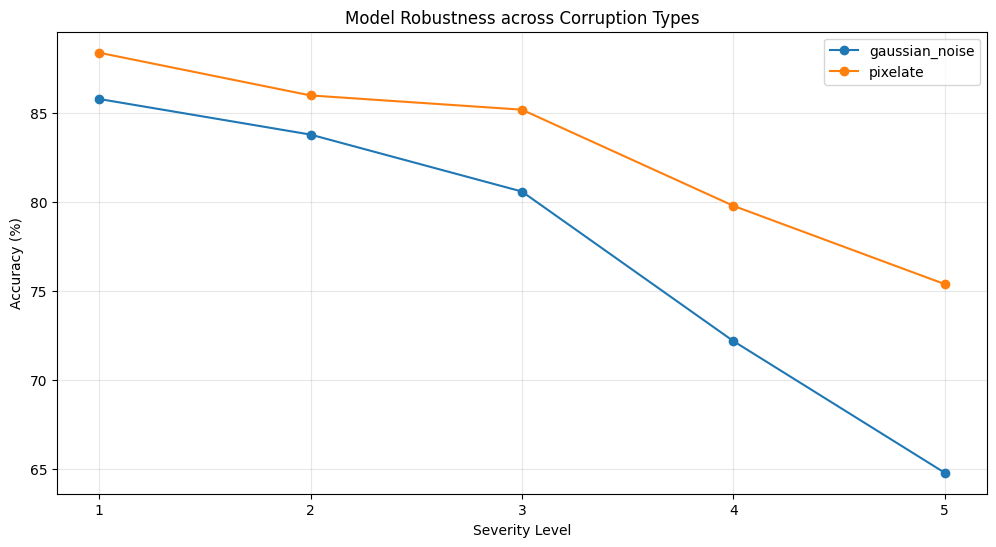

✓ Plot saved to: corruption_evaluation_plot.png
✓ Results copied to Google Drive


In [ ]:
import subprocess
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import shutil

# Checkpoints
CHECKPOINT_DIR = "/content/drive/MyDrive/best_models_resnet"
CHECKPOINT = "final_vit_b_16.pth"

# Corruption
corruption_types = ['gaussian_noise', 'pixelate']

# Severity levels
severity_levels = [1, 2, 3, 4, 5]

# Results storage
results = []

print("="*80)
print("Starting Systematic Corruption Evaluation")
print("="*80)

for corruption in corruption_types:
    print(f"\n{'='*80}")
    print(f"Corruption Type: {corruption.upper()}")
    print("="*80)

    for severity in severity_levels:
        print(f"\n{'-'*80}")
        print(f"Evaluating: {corruption} - Severity Level {severity}")
        print("-"*80)

        # Path to severity level
        data_dir = f"datasets/test/{corruption}/severity_{severity}"

        # Check if path exists
        if not Path(data_dir).exists():
            print(f"Skipping: {data_dir} does not exist")
            continue

        # Run evaluation
        cmd = [
            "python", "-m", "experiments.base_ensemble.scripts.ensemble_inference",
            "--evaluate",
            "--data-dir", data_dir,
            "--split", "",
            "--checkpoints", f"{CHECKPOINT_DIR}/{CHECKPOINT}"
        ]

        try:
            result = subprocess.run(cmd, capture_output=True, text=True, check=True)
            output = result.stdout

            # Overall Accuracy
            accuracy_match = re.search(r'Overall Ensemble Accuracy:\s*(\d+\.\d+)%', output)
            if accuracy_match:
                accuracy = float(accuracy_match.group(1))
                results.append({
                    'Corruption': corruption,
                    'Severity': severity,
                    'Accuracy': accuracy
                })
                print(f"Overall Accuracy {CHECKPOINT}: {accuracy:.2f}%")

            # Print results
            print("\n" + output)

        except subprocess.CalledProcessError as e:
            print(f"Error: {e}")
            print(e.stderr)

print("\n" + "="*80)
print("Evaluation Check")
print("="*80)

df = pd.DataFrame(results)

if not df.empty:
    # Pivot-Table
    pivot_df = df.pivot(index='Severity', columns='Corruption', values='Accuracy')

    print("\n" + "="*80)
    print(f"Final: Accuracy across Corruption Types and Severity Levels for {CHECKPOINT}")
    print("="*80)
    print(pivot_df.to_string())

    # CSV
    df.to_csv(f'{CHECKPOINT}_corruption_evaluation_results.csv', index=False)
    print(f"\nSave: {CHECKPOINT}_corruption_evaluation_results.csv")

    # Plot
    plt.figure(figsize=(12, 6))
    for corruption in df['Corruption'].unique():
        subset = df[df['Corruption'] == corruption]
        plt.plot(subset['Severity'], subset['Accuracy'], marker='o', label=corruption)

    plt.xlabel('Severity Level')
    plt.ylabel('Accuracy (%)')
    plt.title('Model Robustness across Corruption Types')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks([1, 2, 3, 4, 5])
    plt.savefig(f'{CHECKPOINT}_corruption_evaluation_plot.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Plot saved to: {CHECKPOINT}_corruption_evaluation_plot.png")

    # Google Drive
    shutil.copy(f'{CHECKPOINT}_corruption_evaluation_results.csv', '/content/drive/MyDrive/')
    shutil.copy(f'{CHECKPOINT}_corruption_evaluation_plot.png', '/content/drive/MyDrive/')
    print("✓ Results copied to Google Drive")

else:
    print("No results to display.")
    print(f"Results list length: {len(results)}")

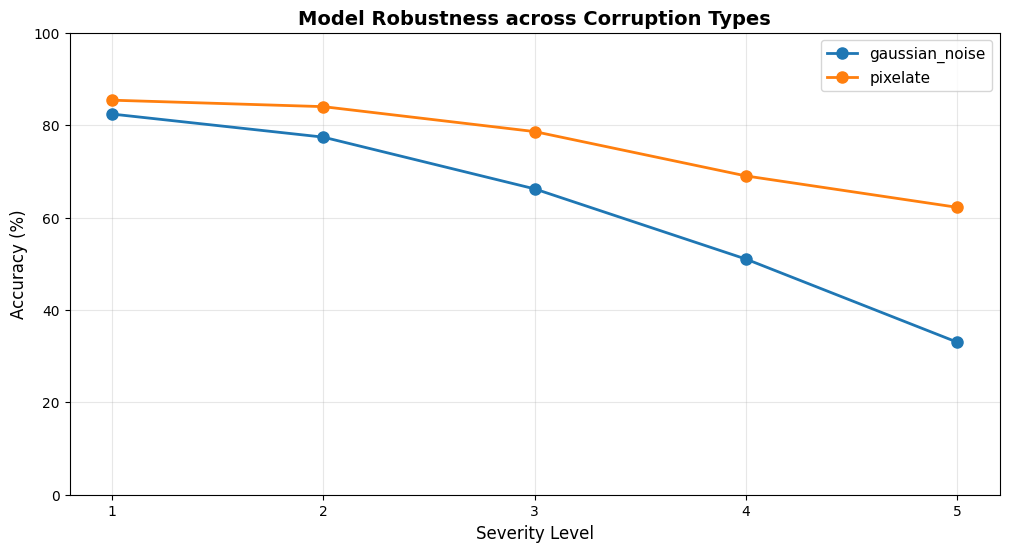

✓ Plot saved and copied to Google Drive


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Laden Sie die CSV
df = pd.read_csv('corruption_evaluation_results.csv')

# Plot erstellen
plt.figure(figsize=(12, 6))
for corruption in df['Corruption'].unique():
    subset = df[df['Corruption'] == corruption]
    plt.plot(subset['Severity'], subset['Accuracy'], marker='o', label=corruption, linewidth=2, markersize=8)

plt.xlabel('Severity Level', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Robustness across Corruption Types', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0, 100)
plt.savefig('corruption_evaluation_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Zu Google Drive kopieren
import shutil
shutil.copy('corruption_evaluation_plot.png', '/content/drive/MyDrive/')
print("✓ Plot saved and copied to Google Drive")

## Optional: Speichern der Ergebnisse auf Google Drive

In [12]:
# Kopieren Sie die Ergebnisse zu Google Drive
!cp corruption_evaluation_results.csv /content/drive/MyDrive/
!cp corruption_evaluation_plot.png /content/drive/MyDrive/

print("✓ Results copied to Google Drive")

✓ Results copied to Google Drive
